In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd

from unidecode import unidecode

In [2]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [3]:
# 1 -- distribution of MNEs
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
region_gdf = gpd.read_file("../data/shape_files/" + str(region_level) + "_shape.geojson")
key_table = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")

In [4]:
# join region codes to shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_nev"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [5]:
# aggregate MNE data
group_col = str(region_level) + "_kod"
region_mne_agg_table = mne_df.groupby(group_col)\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

region_mne_agg_table["mne_firm_share"] = region_mne_agg_table["nr_mnes"] / region_mne_agg_table["nr_firms"]
region_mne_agg_table["mne_emp_share"] = region_mne_agg_table["mne_emp"] / region_mne_agg_table["total_emp"]

In [6]:
# merge MNE data to map
key_col = str(region_level) + "_kod"
plot_df = pd.merge(
    plot_df,
    region_mne_agg_table,
    on=key_col,
    how="left"
)

In [7]:
def plot_mnes_on_map(df, key_var, colormap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_var, cmap=colormap, edgecolor="white", linewidth=0.15, ax=ax)
    
    # colorbar
    vmin = df[key_var].min()
    vmax = df[key_var].max()
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

# plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=14)

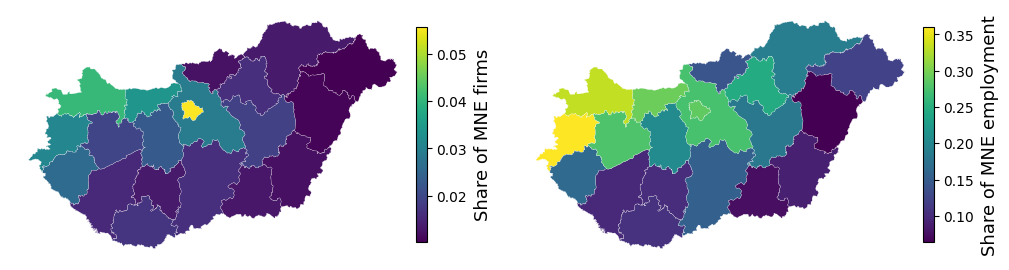

In [8]:
# grid of different plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_mnes_on_map(plot_df, key_var="mne_firm_share", colormap="viridis", label_text="Share of MNE firms", fontsize=13, ax=ax[0])
plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=13, ax=ax[1])

In [5]:
# MNEs per industry figure
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

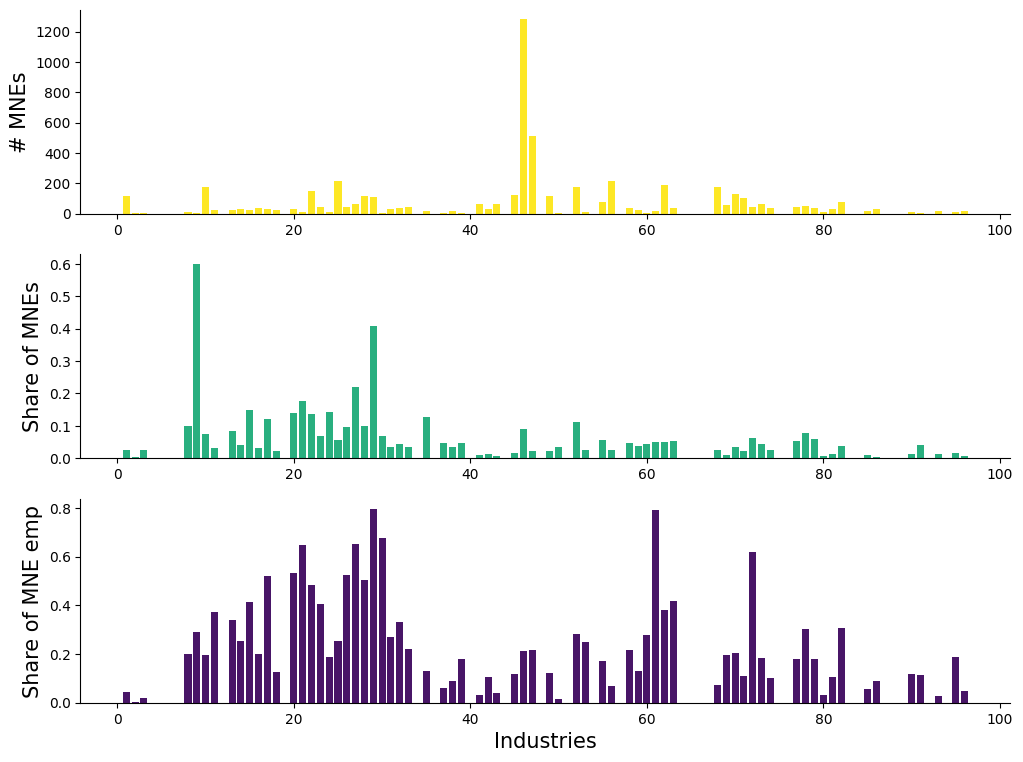

In [16]:
def plot_mne_per_industry(df, ind_col, key_col, color_code, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_col], df[key_col], color=color_code)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])


In [ ]:
# network visual


In [ ]:
# illustration plot -- selected NUTS3
plot_df["selected_region"] = 0
plot_df.loc[plot_df["region_name"] == "Bacs-Kiskun", ["selected_region"]] = 1

fig, ax = plt.subplots(1,1, figsize=(6,5))
plot_df[plot_df["selected_region"]==1].plot(column="selected_region", color="#096607", ax=ax)
plot_df.boundary.plot(color="black", linewidth=0.25, ax=ax)

In [7]:
# coagg / IO / SR matrix visuals
el1 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_oc.csv", sep=";")

def norm01(values):
    new_values = (values - min(values)) / (max(values) - min(values))
    return new_values

def z_score(values):
    new_values = (values - np.mean(values)) / (max(values) - min(values))
    return new_values

In [83]:
# variables manipulation
el1["egk_coagg_norm"] = norm01(el1["egk_coagg"])
el1["egk_coagg_z"] = z_score(el1["egk_coagg"])

el1["log_undir_value"] = np.log10(el1["undir_value"])
el1.replace([np.inf, -np.inf], 0, inplace=True)

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


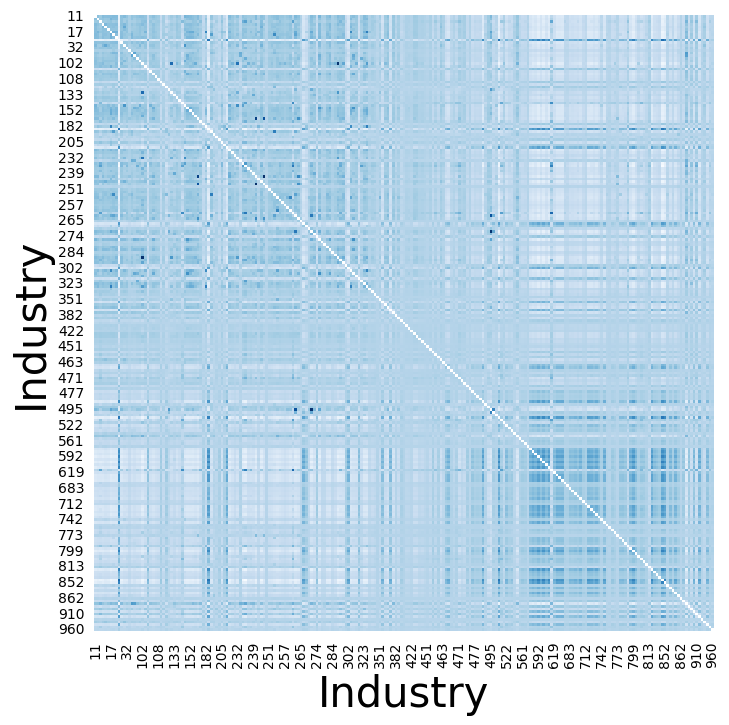

In [90]:
def mpp_matrix(df, key_cols, sort_matrix, heatmap, fontsize, cmap, ax=None):
    """matrix visualization"""
    table = df[key_cols]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_cols]
    table = pd.concat([table, table2])

    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
     
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
  
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "egk_coagg_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Blues", ax=None)

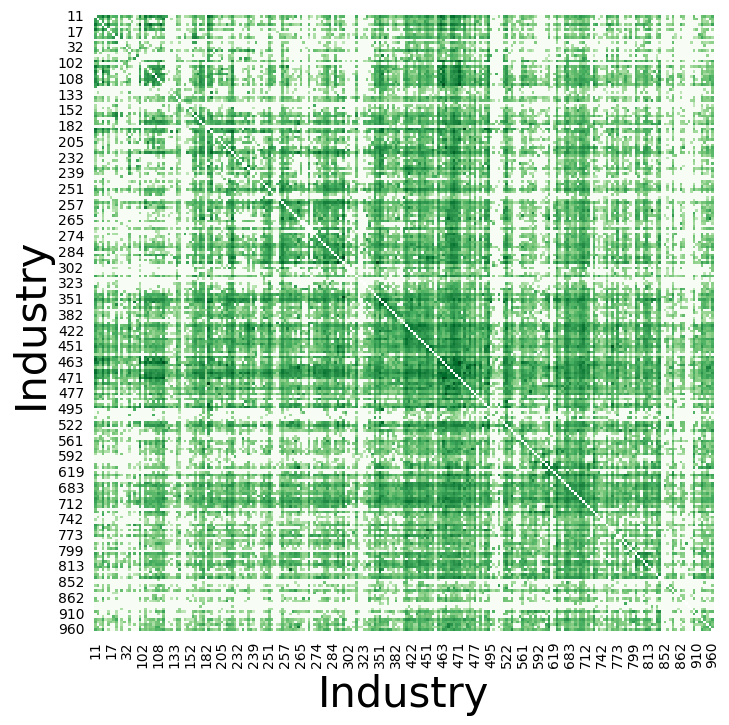

In [91]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "log_undir_value"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Greens", ax=None)

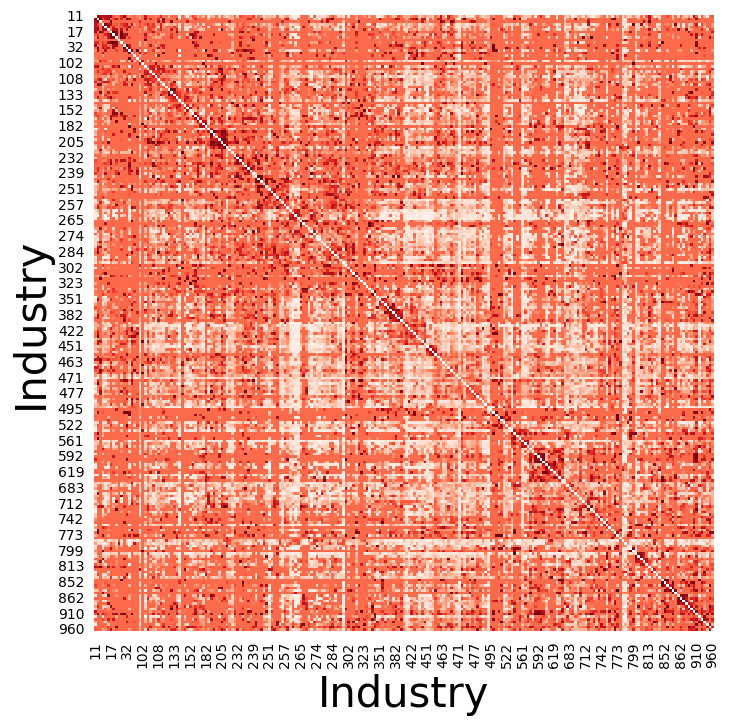

In [92]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "hun_sr_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Reds", ax=None)
